# Spatial Topic Comparison

This notebook joins point-capable service-request records to the packaged NYC community-district layer and compares complaint mix by joined district.

The goal is to show the reusable `nyc311.spatial` and packaged geography helpers directly on the bundled offline sample data, then preview the joined points entirely in memory.

In [1]:
import nyc311
from IPython.display import display

records = nyc311.load_sample_service_requests()
sample_boundaries = nyc311.load_sample_boundaries("community_district")
records_gdf = nyc311.records_to_geodataframe(records)
boundaries_gdf = nyc311.load_boundaries_geodataframe(sample_boundaries)
joined = nyc311.spatially_enrich_records(
    records,
    boundaries=sample_boundaries,
)
joined.head()

,service_request_id,created_date,complaint_type,descriptor,borough,community_district,resolution_description,latitude,longitude,geometry,boundary_geography,boundary_geography_value,boundary_boro_cd,boundary_borough,boundary_district_number,boundary_name,boundary_shape_area,boundary_shape_length
0,1001,2025-01-05,Noise - Residential,Loud party music after midnight,BROOKLYN,BROOKLYN 01,Officers advised occupants to lower music,40.730,-73.960,POINT (-73.96 40.73),community_district,BROOKLYN 01,301.0,BROOKLYN,1.0,Brooklyn Community District 1,1.316955e+08,69237.885113
1,1002,2025-01-07,Noise - Residential,Banging and hammering from upstairs apartment,BROOKLYN,BROOKLYN 01,Condition resolved after inspection,40.730,-73.960,POINT (-73.96 40.73),community_district,BROOKLYN 01,301.0,BROOKLYN,1.0,Brooklyn Community District 1,1.316955e+08,69237.885113
2,1003,2025-01-11,Noise - Residential,Construction drilling started before 7am,BROOKLYN,BROOKLYN 03,Referred to construction enforcement,40.685,-73.935,POINT (-73.935 40.685),community_district,BROOKLYN 03,303.0,BROOKLYN,3.0,Brooklyn Community District 3,7.946168e+07,36213.675395
3,1004,2025-01-17,Noise - Residential,Dog barking continuously in rear yard,BROOKLYN,BROOKLYN 03,Caller advised to document recurrence,40.685,-73.935,POINT (-73.935 40.685),community_district,BROOKLYN 03,303.0,BROOKLYN,3.0,Brooklyn Community District 3,7.946168e+07,36213.675395
4,1005,2025-02-02,Noise - Residential,Television and stereo too loud next door,MANHATTAN,MANHATTAN 10,Building staff contacted resident,40.815,-73.940,POINT (-73.94 40.815),community_district,MANHATTAN 10,110.0,MANHATTAN,10.0,Manhattan Community District 10,3.907378e+07,35890.251738


In [2]:
comparison = (
    joined.dropna(subset=["boundary_geography_value"])
    .groupby(["boundary_geography_value", "complaint_type"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["boundary_geography_value", "count"], ascending=[True, False])
)

display(comparison)

,boundary_geography_value,complaint_type,count
2,BROOKLYN 01,Noise - Residential,2
0,BROOKLYN 01,Blocked Driveway,1
1,BROOKLYN 01,Illegal Parking,1
3,BROOKLYN 01,Rodent,1
4,BROOKLYN 03,Noise - Residential,2
5,BROOKLYN 03,Rodent,1
7,MANHATTAN 10,Noise - Residential,2
6,MANHATTAN 10,Blocked Driveway,1
8,MANHATTAN 10,Rodent,1


,boundary_geography_value,complaint_type,count
2,BROOKLYN 01,Noise - Residential,2
0,BROOKLYN 01,Blocked Driveway,1
1,BROOKLYN 01,Illegal Parking,1
4,BROOKLYN 03,Noise - Residential,2
5,BROOKLYN 03,Rodent,1
7,MANHATTAN 10,Noise - Residential,2
6,MANHATTAN 10,Blocked Driveway,1
8,MANHATTAN 10,Rodent,1


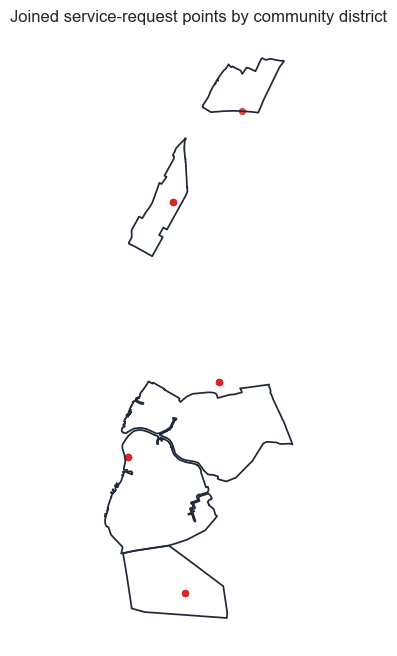

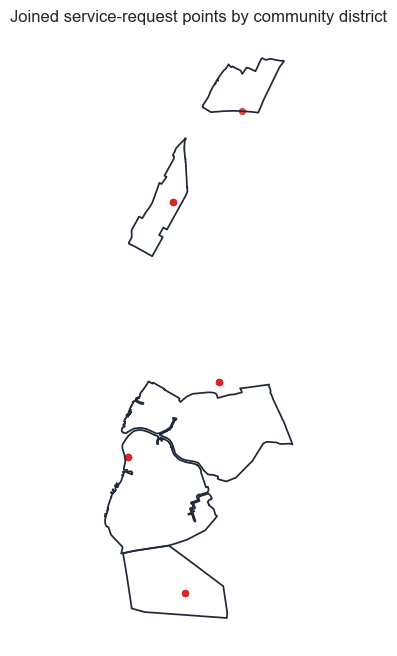

In [3]:
top_by_district = comparison.groupby("boundary_geography_value").head(3)
display(top_by_district)

figure = nyc311.plot_boundary_preview(
    boundaries_gdf,
    points_gdf=records_gdf,
    title="Joined service-request points by community district",
)
figure